# Reconocimiento e Identificación de Placas Vehiculares
### Módulo 3 · Visión por Computadora · Diplomado RNA y Deep Learning
---
## Análisis del dataset

| Imagen | Texto real | Tipo | Dificultad |
|--------|-----------|------|------------|
| placa1 | LRV-59-77 | 🇲🇽 EdomEx gris | ✅ Close-up |
| placa2 | 5649 JSN  | 🇪🇸 España (EU) | ✅ Close-up |
| placa3 | NLU-96-03 | 🇲🇽 EdomEx oscura | ⚠️ Noche |
| placa4 | NAA-77-41 | 🇲🇽 EdomEx colorida | ✅ Close-up |
| placa5 | BNR-249   | 🇨🇴 Colombia amarilla | 🔴 Escena calle |
| placa6 | NNR-70-87 | 🇲🇽 CDMX | 🔴 Escena calle |
| placa7 | 470-MJV   | 🇲🇽 CDMX | 🔴 Escena calle |

## Pipeline implementado
```
Imagen → Haar Cascade (detecta región) → Filtros AR+contraste
       → Identificar tipo (MX/EU/CO) por color
       → Crop zona numérica por tipo
       → Preprocesamiento (CLAHE + mediana + binarizar)
       → Auto-inversión (garantiza texto oscuro en fondo claro)
       → OCR Tesseract (PSM 7 normal / PSM 6 fallback)
       → Extracción por regex → Scoring por formato → Resultado
```
## Historial de versiones
| Ver | Mejora |
|-----|--------|
| v1 | Base: Haar + OCR básico |
| v2 | cargar_imagenes() dinámico, Colombia, rutas multiplataforma |
| v3 | Filtro AR, morphología, zona de números |
| v4 | Filtro contraste, scoring por formato |
| v5 | Auto-inversión, thresholds fijos |
| v6 | Regex por tipo, token scoring, padding ROI |
| **v6f** | **Todas las correcciones integradas, orden correcto** |


---
## Notas de Instalación — Tesseract OCR
### Windows 11
```
1. https://github.com/UB-Mannheim/tesseract/wiki → tesseract-ocr-w64-setup-*.exe
2. Instalar. Ruta: C:\Program Files\Tesseract-OCR\tesseract.exe
3. Reiniciar kernel.
```
### Ubuntu
```bash
sudo apt update && sudo apt install tesseract-ocr libtesseract-dev
```
### Google Colab
```python
!sudo apt install tesseract-ocr -q && pip install pytesseract -q
from google.colab import drive; drive.mount('/content/drive')
```


In [50]:
# ═══════════════════════════════════════════════════════════════
# CELDA 1 — Imports y configuración global
# ═══════════════════════════════════════════════════════════════
import cv2, numpy as np, matplotlib.pyplot as plt
import os, re, platform, pytesseract

if platform.system() == 'Windows':
    pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

RUTA_PLACAS      = os.path.join('..', 'Material', 'Plates')
EXTENSIONES_IMG  = ('.jpg', '.jpeg', '.png', '.bmp')
AR_MIN, AR_MAX   = 1.5, 7.0
BRILLO_MIN       = 35           # stddev mínimo — árboles≈15-25, placas≈35-80
PADDING_ROI      = 0.08
KERNEL_MORPH     = np.ones((2,2), np.uint8)
THRESHOLDS_FIJOS = [80, 110, 130, 160]

OCR_CFG = {
    'MX' : '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-',
    'EU' : '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789',
    'CO' : '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-',
    'GEN': '--psm 6 --oem 3',
}
PATRONES_PLACA = {
    'MX' : r'[A-Z]{2,3}[-]?\d{2}[-]?\d{2}',
    'EU' : r'\d{4}[A-Z]{2,3}',
    'CO' : r'[A-Z]{3}[-]?\d{3}',
    'GEN': r'[A-Z0-9]{5,9}',
}
RANGO_CHARS = {'MX':(5,8),'EU':(6,8),'CO':(5,7),'GEN':(4,10)}

GROUND_TRUTH = {
    'placa1.jpg': ('LRV5977','MX'),
    'placa2.jpg': ('5649JSN','EU'),
    'placa3.jpg': ('NLU9603','MX'),
    'placa4.jpg': ('NAA7741','MX'),
    'placa5.jpg': ('BNR249', 'CO'),
    'placa6.jpg': ('NNR7087','MX'),
    'placa7.jpg': ('470MJV', 'MX'),
}

print(f'Sistema   : {platform.system()}')
print(f'Ruta      : {os.path.abspath(RUTA_PLACAS)}')
print(f'Tesseract : {pytesseract.get_tesseract_version()}')
print('Imports listos ✅')


Sistema   : Windows
Ruta      : f:\Proyectos\Diplomado-RNA\Modulo-3\Material\Plates
Tesseract : 5.5.0.20241111
Imports listos ✅


In [51]:
# ═══════════════════════════════════════════════════════════════
# CELDA 2 — Haar Cascade
# ═══════════════════════════════════════════════════════════════
plate_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml')
print('Haar Cascade cargado ✅')


Haar Cascade cargado ✅


In [52]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3 — Funciones auxiliares
# Todas en una celda: sin problemas de orden de dependencias.
# ═══════════════════════════════════════════════════════════════

# ── cargar_imagenes ───────────────────────────────────────────
def cargar_imagenes(ruta_carpeta, prefijos=None, ordenar=True):
    """Escanea carpeta. Funciona con cualquier tamaño de dataset."""
    if not os.path.isdir(ruta_carpeta):
        print(f'Carpeta no encontrada: {os.path.abspath(ruta_carpeta)}')
        return []
    archivos = [os.path.join(ruta_carpeta, n)
                for n in os.listdir(ruta_carpeta)
                if n.lower().endswith(EXTENSIONES_IMG)
                and (not prefijos or n.lower().startswith(prefijos))]
    return sorted(archivos) if ordenar else archivos


# ── identificar_tipo_placa ────────────────────────────────────
def identificar_tipo_placa(img_placa_rgb):
    """
    Identifica tipo por color:
    EU → franja azul izquierda (H=100-135, umbral 20%)
    CO → fondo amarillo dominante (H=20-35, umbral 12%)
    MX → default
    """
    h, w = img_placa_rgb.shape[:2]
    hsv  = cv2.cvtColor(img_placa_rgb, cv2.COLOR_RGB2HSV)
    franja  = hsv[:, :int(w*0.15)]
    mask_eu = cv2.inRange(franja, np.array([100,100,80]), np.array([135,255,255]))
    score_eu = cv2.countNonZero(mask_eu) / max(franja.shape[0]*franja.shape[1],1) * 100
    mask_co  = cv2.inRange(hsv, np.array([20,150,150]), np.array([35,255,255]))
    score_co = cv2.countNonZero(mask_co) / max(h*w,1) * 100
    info = {'eu':round(score_eu,1),'co':round(score_co,1)}
    if score_eu > 5: return 'EU', info         # antes 10, placa2 tiene 9.6%
    if score_co > 3: return 'CO', info         # antes 10, placa5 tiene 3.5%
    return 'MX', info


# ── filtrar_detecciones ───────────────────────────────────────
def filtrar_detecciones(dets, img_rgb, ar_min=AR_MIN, ar_max=AR_MAX,
                        brillo_min=BRILLO_MIN):
    """
    Filtra detecciones por aspect ratio y contraste (stddev).
    AR: placas son rectangulares horizontales (1.5 - 7.0)
    Contraste: stddev>35 descarta árboles/cielo homogéneos
    """
    validas, descartadas = [], []
    for det in dets:
        x,y,w,h = det
        ar  = round(w/h,2) if h else 0
        rec = img_rgb[y:y+h, x:x+w]
        std = round(float(np.std(cv2.cvtColor(rec,cv2.COLOR_RGB2GRAY))),1)
        if not (ar_min <= ar <= ar_max):
            descartadas.append(f'AR={ar}')
        elif std < brillo_min:
            descartadas.append(f'contraste={std}<{brillo_min}')
        else:
            validas.append(det)
    return validas, descartadas


# ── score_ocr_resultado ───────────────────────────────────────
def score_ocr_resultado(texto, tipo):
    """
    Puntúa un texto OCR según formato de placa esperado.
    + puntos por longitud en rango, guiones (MX/CO), mezcla letras+nums.
    - puntos por exceso de longitud o guiones inesperados (EU).
    """
    if not texto: return -99
    chars = texto.replace('-','')
    n_ch  = len(chars)
    n_gui = texto.count('-')
    mix   = any(c.isalpha() for c in chars) and any(c.isdigit() for c in chars)
    rmin,rmax = RANGO_CHARS.get(tipo,(4,10))
    score = 0
    score += 20 if rmin<=n_ch<=rmax else -5*(max(0,n_ch-rmax)+max(0,rmin-n_ch))
    if tipo in ('MX','CO'): score += 15*min(n_gui,2)
    elif tipo=='EU':        score -= 5*n_gui
    if mix: score += 10
    score += n_ch
    return score


# ── extraer_patron_placa ──────────────────────────────────────
def extraer_patron_placa(texto_ocr, tipo):
    """
    Extrae el número de placa de texto OCR potencialmente ruidoso.
    Nivel 1: regex del formato de placa dentro del texto
    Nivel 2: token scoring (palabra con mayor score)
    Nivel 3: texto original
    """
    if not texto_ocr: return '', 'vacio'
    patron = PATRONES_PLACA.get(tipo, PATRONES_PLACA['GEN'])
    matches = re.findall(patron, texto_ocr)
    if matches:
        mejor = max(matches, key=lambda m: score_ocr_resultado(m,tipo))
        return mejor, 'regex'
    tokens = [t for t in texto_ocr.split() if len(t)>=3]
    if tokens:
        scored = [(t, score_ocr_resultado(t,tipo)) for t in tokens]
        mejor_t, mejor_s = max(scored, key=lambda x: x[1])
        if mejor_s > 0: return mejor_t, 'token'
    return texto_ocr, 'original'


# ── auto_invertir ─────────────────────────────────────────────
def auto_invertir(img_bin):
    """Garantiza texto oscuro sobre fondo claro (requerido por Tesseract)."""
    if np.mean(img_bin) < 127:
        return cv2.bitwise_not(img_bin), True
    return img_bin, False


# ── normalizar y verificar_ocr ────────────────────────────────
def normalizar(texto):
    """Quita guiones/espacios y pone en mayúsculas para comparación."""
    return ''.join(c for c in texto.upper() if c.isalnum())

def verificar_ocr(texto_ocr, ground_truth):
    """
    Verifica si el OCR es correcto con comparación normalizada.
    FIX: string vacío NUNCA es correcto (en Python '' in 'abc' = True).
    """
    if not ground_truth or ground_truth=='?': return ' — '
    ocr_n = normalizar(texto_ocr)
    gt_n  = normalizar(ground_truth)
    if not ocr_n: return '❌'    # vacío siempre incorrecto
    if ocr_n==gt_n or gt_n in ocr_n or ocr_n in gt_n: return '✅'
    return '❌'


print('Funciones auxiliares listas ✅')
print('  cargar_imagenes | identificar_tipo_placa | filtrar_detecciones')
print('  score_ocr_resultado | extraer_patron_placa')
print('  auto_invertir | normalizar | verificar_ocr')


Funciones auxiliares listas ✅
  cargar_imagenes | identificar_tipo_placa | filtrar_detecciones
  score_ocr_resultado | extraer_patron_placa
  auto_invertir | normalizar | verificar_ocr


In [53]:
# ═══════════════════════════════════════════════════════════════
# CELDA 4 — detectar_placas()
# ═══════════════════════════════════════════════════════════════

def aplicar_padding(x,y,w,h,img_h,img_w,padding=PADDING_ROI):
    """Expande bbox un % en cada dirección sin salirse de la imagen."""
    dx,dy = int(w*padding), int(h*padding)
    return (max(0,x-dx), max(0,y-dy),
            min(img_w,x+w+dx)-max(0,x-dx),
            min(img_h,y+h+dy)-max(0,y-dy))


def detectar_placas(ruta_imagen):
    """
    Detecta placas vehiculares con 4 intentos progresivos.
    Cada intento aplica filtros de AR y contraste.
    Si todos fallan: fallback con imagen completa.
    """
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None:
        print(f'  No se pudo cargar: {ruta_imagen}'); return None,[],[],- 1
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    H,W = img_rgb.shape[:2]
    intentos = [
        (1.10,5,(60,20),'estandar'),
        (1.05,3,(40,15),'permisivo'),
        (1.03,1,(30,10),'ultra-permisivo'),
        (1.03,1,(20, 8),'escena-calle'),
    ]
    for num,(scale,vecinos,minsize,desc) in enumerate(intentos,1):
        dets = plate_cascade.detectMultiScale(
            img_gris,scaleFactor=scale,minNeighbors=vecinos,minSize=minsize)
        if len(dets)==0: continue
        validas,descartadas = filtrar_detecciones(dets,img_rgb)
        if descartadas: print(f'  Intento {num}: {len(descartadas)} rechazada(s)')
        if not validas: continue
        dets_pad = [aplicar_padding(x,y,w,h,H,W) for (x,y,w,h) in validas]
        dets_pad = sorted(dets_pad,key=lambda r:r[2]*r[3],reverse=True)
        recortes = [img_rgb[y:y+h,x:x+w] for (x,y,w,h) in dets_pad]
        print(f'  Intento {num} ({desc}): {len(validas)} válida(s)')
        return img_rgb,recortes,dets_pad,num
    print('  Sin detecciones válidas → fallback imagen completa')
    return img_rgb,[img_rgb],[(0,0,W,H)],0


print('detectar_placas() lista ✅')


detectar_placas() lista ✅


In [54]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5 — extraer_texto()
# ═══════════════════════════════════════════════════════════════

def extraer_texto(img_placa_rgb, tipo='MX', escala=2.0, es_fallback=False):
    """
    Pipeline OCR completo:
    crop por tipo → escala → grises → CLAHE → mediana
    → binarizar (otsu + adapt + thresholds fijos)
    → auto-inversión → OCR → extraer_patron_placa → score

    PSM adaptativo:
      PSM 7 = una línea → para recortes de placa
      PSM 6 = bloque    → para fallback (imagen completa)
    """
    if es_fallback:
        config_ocr = '--psm 6 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-'
    else:
        config_ocr = OCR_CFG.get(tipo, OCR_CFG['GEN'])

    # Crop por tipo (solo si NO es fallback)
    h_img,w_img = img_placa_rgb.shape[:2]
    if not es_fallback:
        if   tipo=='MX': zona = img_placa_rgb[int(h_img*0.45):int(h_img*0.90),:]
        elif tipo=='EU': zona = img_placa_rgb[:,int(w_img*0.13):]
        else:            zona = img_placa_rgb
        img_base = zona if (zona.shape[0]>10 and zona.shape[1]>10) else img_placa_rgb
    else:
        img_base = img_placa_rgb  # fallback: imagen completa sin crop

    # Preprocesamiento
    h,w     = img_base.shape[:2]
    img_esc = cv2.resize(img_base,(int(w*escala),int(h*escala)),
                         interpolation=cv2.INTER_CUBIC)
    g       = cv2.cvtColor(img_esc,cv2.COLOR_RGB2GRAY)
    clahe   = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
    g_cla   = clahe.apply(g)
    g_med   = cv2.medianBlur(g_cla,3)

    # Binarizaciones: Otsu + Adaptativa + Morphológica + Fijas
    _,b_ot  = cv2.threshold(g_med,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    b_ad    = cv2.adaptiveThreshold(g_med,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY,11,2)
    b_mo    = cv2.morphologyEx(b_ot,cv2.MORPH_CLOSE,KERNEL_MORPH)
    bins    = {'otsu':b_ot,'adapt':b_ad,'morph':b_mo}
    for t in THRESHOLDS_FIJOS:
        _,bt = cv2.threshold(g_med,t,255,cv2.THRESH_BINARY)
        bins[f't{t}']     = bt
        bins[f't{t}_inv'] = cv2.bitwise_not(bt)

    # OCR en cada variante
    detalle,scores = {},{}
    for nombre,img_bin in bins.items():
        img_c,_ = auto_invertir(img_bin)
        raw     = pytesseract.image_to_string(img_c,config=config_ocr)
        limpio  = ''.join(c for c in raw.upper() if c.isalnum() or c in '- ')
        ext,met = extraer_patron_placa(limpio.strip(),tipo)
        detalle[nombre] = (limpio.strip(),ext,met)
        scores[nombre]  = score_ocr_resultado(ext,tipo)

    mejor_var   = max(scores,key=lambda k:scores[k])
    texto_final = detalle[mejor_var][1]
    
    # Si no hay dígitos → probablemente leyó el logo, no la placa
    # Reintentamos sin crop (imagen completa)
    
    if not any(c.isdigit() for c in texto_final) and not es_fallback:
        texto_retry, detalle_r, scores_r, mejor_r, _ = extraer_texto(
            img_placa_rgb, tipo=tipo, escala=escala, es_fallback=True)
        if any(c.isdigit() for c in texto_retry):
            texto_final = texto_retry
            mejor_var   = mejor_r

    ot_c,_ = auto_invertir(b_ot)
    t130   = bins.get('t130',bins.get('t110',b_ot))
    t130_c,_ = auto_invertir(t130)
    etapas  = {
        'original':img_placa_rgb, 'zona':img_base,
        'clahe':g_cla, 'otsu':ot_c, 't130':t130_c,
    }
    return texto_final,detalle,scores,mejor_var,etapas


print('extraer_texto() lista ✅')
print('  PSM 7 para recortes de placa | PSM 6 para fallback (imagen completa)')


extraer_texto() lista ✅
  PSM 7 para recortes de placa | PSM 6 para fallback (imagen completa)


In [55]:
# ═══════════════════════════════════════════════════════════════
# CELDA 6 — Procesamiento completo
# ═══════════════════════════════════════════════════════════════

imagenes   = cargar_imagenes(RUTA_PLACAS, prefijos=('placa',))
resultados = []

for ruta in imagenes:
    nombre = os.path.basename(ruta)
    print(f'\n{"="*60}\n  {nombre}\n{"="*60}')

    img_rgb,recortes,coords,intento_ok = detectar_placas(ruta)
    if img_rgb is None: continue

    es_fallback = (intento_ok == 0)
    recorte     = recortes[0]
    tipo,info   = identificar_tipo_placa(recorte)
    print(f'  Tipo: {tipo}  EU={info["eu"]}%  CO={info["co"]}%  fallback={es_fallback}')

    texto,detalle,scores,mejor_var,etapas = extraer_texto(
        recorte, tipo=tipo, es_fallback=es_fallback)

    raw,ext,met = detalle[mejor_var]
    gt,_        = GROUND_TRUTH.get(nombre,('?','?'))
    resultado   = verificar_ocr(texto, gt)

    print(f'  Raw OCR  : [{raw[:55]}]')
    print(f'  Extraído : [{ext}]  via={mejor_var}({met})')
    print(f'  Esperado : [{gt}]  {resultado}')

    top3 = sorted(scores.items(),key=lambda x:-x[1])[:3]
    print('  Top3: ' + ' | '.join(f'{k}(s={v}):[{detalle[k][1]}]' for k,v in top3))

    resultados.append({'imagen':nombre,'tipo':tipo,'texto':texto,'raw':raw,
                       'metodo':met,'mejor':mejor_var,'intento':intento_ok,
                       'es_fallback':es_fallback,'recorte':recorte,'etapas':etapas,
                        'detalle': detalle})

print(f'\n\nProcesamiento completo: {len(resultados)} imagen(es) ✅')



  placa1.jpg
  Sin detecciones válidas → fallback imagen completa
  Tipo: MX  EU=0.0%  CO=0.0%  fallback=True
  Raw OCR  : [RD TOLRV-59-77]
  Extraído : [LRV-59-77]  via=otsu(regex)
  Esperado : [LRV5977]  ✅
  Top3: otsu(s=67):[LRV-59-77] | morph(s=67):[LRV-59-77] | t110(s=67):[LRV-59-77]

  placa2.jpg
  Intento 1 (estandar): 2 válida(s)
  Tipo: EU  EU=9.6%  CO=0.0%  fallback=False
  Raw OCR  : [15649JSNIS]
  Extraído : [5649JSN]  via=t110(regex)
  Esperado : [5649JSN]  ✅
  Top3: t110(s=37):[5649JSN] | t110_inv(s=37):[5649JSN] | adapt(s=-2):[55K]

  placa3.jpg
  Intento 2 (permisivo): 1 válida(s)
  Tipo: MX  EU=0.0%  CO=0.0%  fallback=False
  Raw OCR  : [EXD]
  Extraído : [EXD]  via=t110(original)
  Esperado : [NLU9603]  ❌
  Top3: otsu(s=27):[EDQANEX] | morph(s=27):[EDOANEX] | t160(s=27):[EDOASEX]

  placa4.jpg
  Sin detecciones válidas → fallback imagen completa
  Tipo: MX  EU=1.1%  CO=0.0%  fallback=True
  Raw OCR  : [NAA-77-41]
  Extraído : [NAA-77-41]  via=otsu(regex)
  Esperado :

In [56]:
# ═══════════════════════════════════════════════════════════════
# CELDA 7 — Tabla de resultados y accuracy
# ═══════════════════════════════════════════════════════════════

sep = '='*80
print('\n'+sep)
print(f'  {"IMAGEN":<12} {"TIPO":<5} {"OCR":<18} {"ESPERADO":<12} {"MÉTODO":<14} {"OCR":>4} {"TIPO":>5}')
print(sep)

c_ocr=c_tipo=0
total = len(resultados)

for r in resultados:
    gt,gt_tipo = GROUND_TRUTH.get(r['imagen'],('?','?'))
    v_ocr  = verificar_ocr(r['texto'], gt)
    v_tipo = '✅' if r['tipo']==gt_tipo else '❌'
    if v_ocr =='✅': c_ocr  += 1
    if v_tipo=='✅': c_tipo += 1
    print(f'  {r["imagen"]:<12} {r["tipo"]:<5} {r["texto"]:<18} '
          f'{gt:<12} {r["metodo"]:<14} {v_ocr:>4} {v_tipo:>5}')

print(sep)
print(f'  Accuracy OCR  : {c_ocr}/{total} = {c_ocr/total*100:.0f}%')
print(f'  Accuracy tipo : {c_tipo}/{total} = {c_tipo/total*100:.0f}%')
print(f'  (Verificación normalizada: guiones/espacios ignorados al comparar)')



  IMAGEN       TIPO  OCR                ESPERADO     MÉTODO          OCR  TIPO
  placa1.jpg   MX    LRV-59-77          LRV5977      regex             ✅     ✅
  placa2.jpg   EU    5649JSN            5649JSN      regex             ✅     ✅
  placa3.jpg   MX    F5G-EX             NLU9603      original          ❌     ✅
  placa4.jpg   MX    NAA-77-41          NAA7741      regex             ✅     ✅
  placa5.jpg   CO                       BNR249       vacio             ❌     ✅
  placa6.jpg   MX    DSS                NNR7087      original          ❌     ✅
  placa7.jpg   MX    SSP                470MJV       original          ❌     ✅
  Accuracy OCR  : 3/7 = 43%
  Accuracy tipo : 7/7 = 100%
  (Verificación normalizada: guiones/espacios ignorados al comparar)


C:\Users\Darck\AppData\Local\Temp\ipykernel_6972\1617544006.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Darck\AppData\Local\Temp\ipykernel_6972\1617544006.py:31: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Darck\AppData\Local\Temp\ipykernel_6972\1617544006.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('output_placas_v6f.png',dpi=120,bbox_inches='tight')
C:\Users\Darck\AppData\Local\Temp\ipykernel_6972\1617544006.py:32: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('output_placas_v6f.png',dpi=120,bbox_inches='tight')
c:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Us

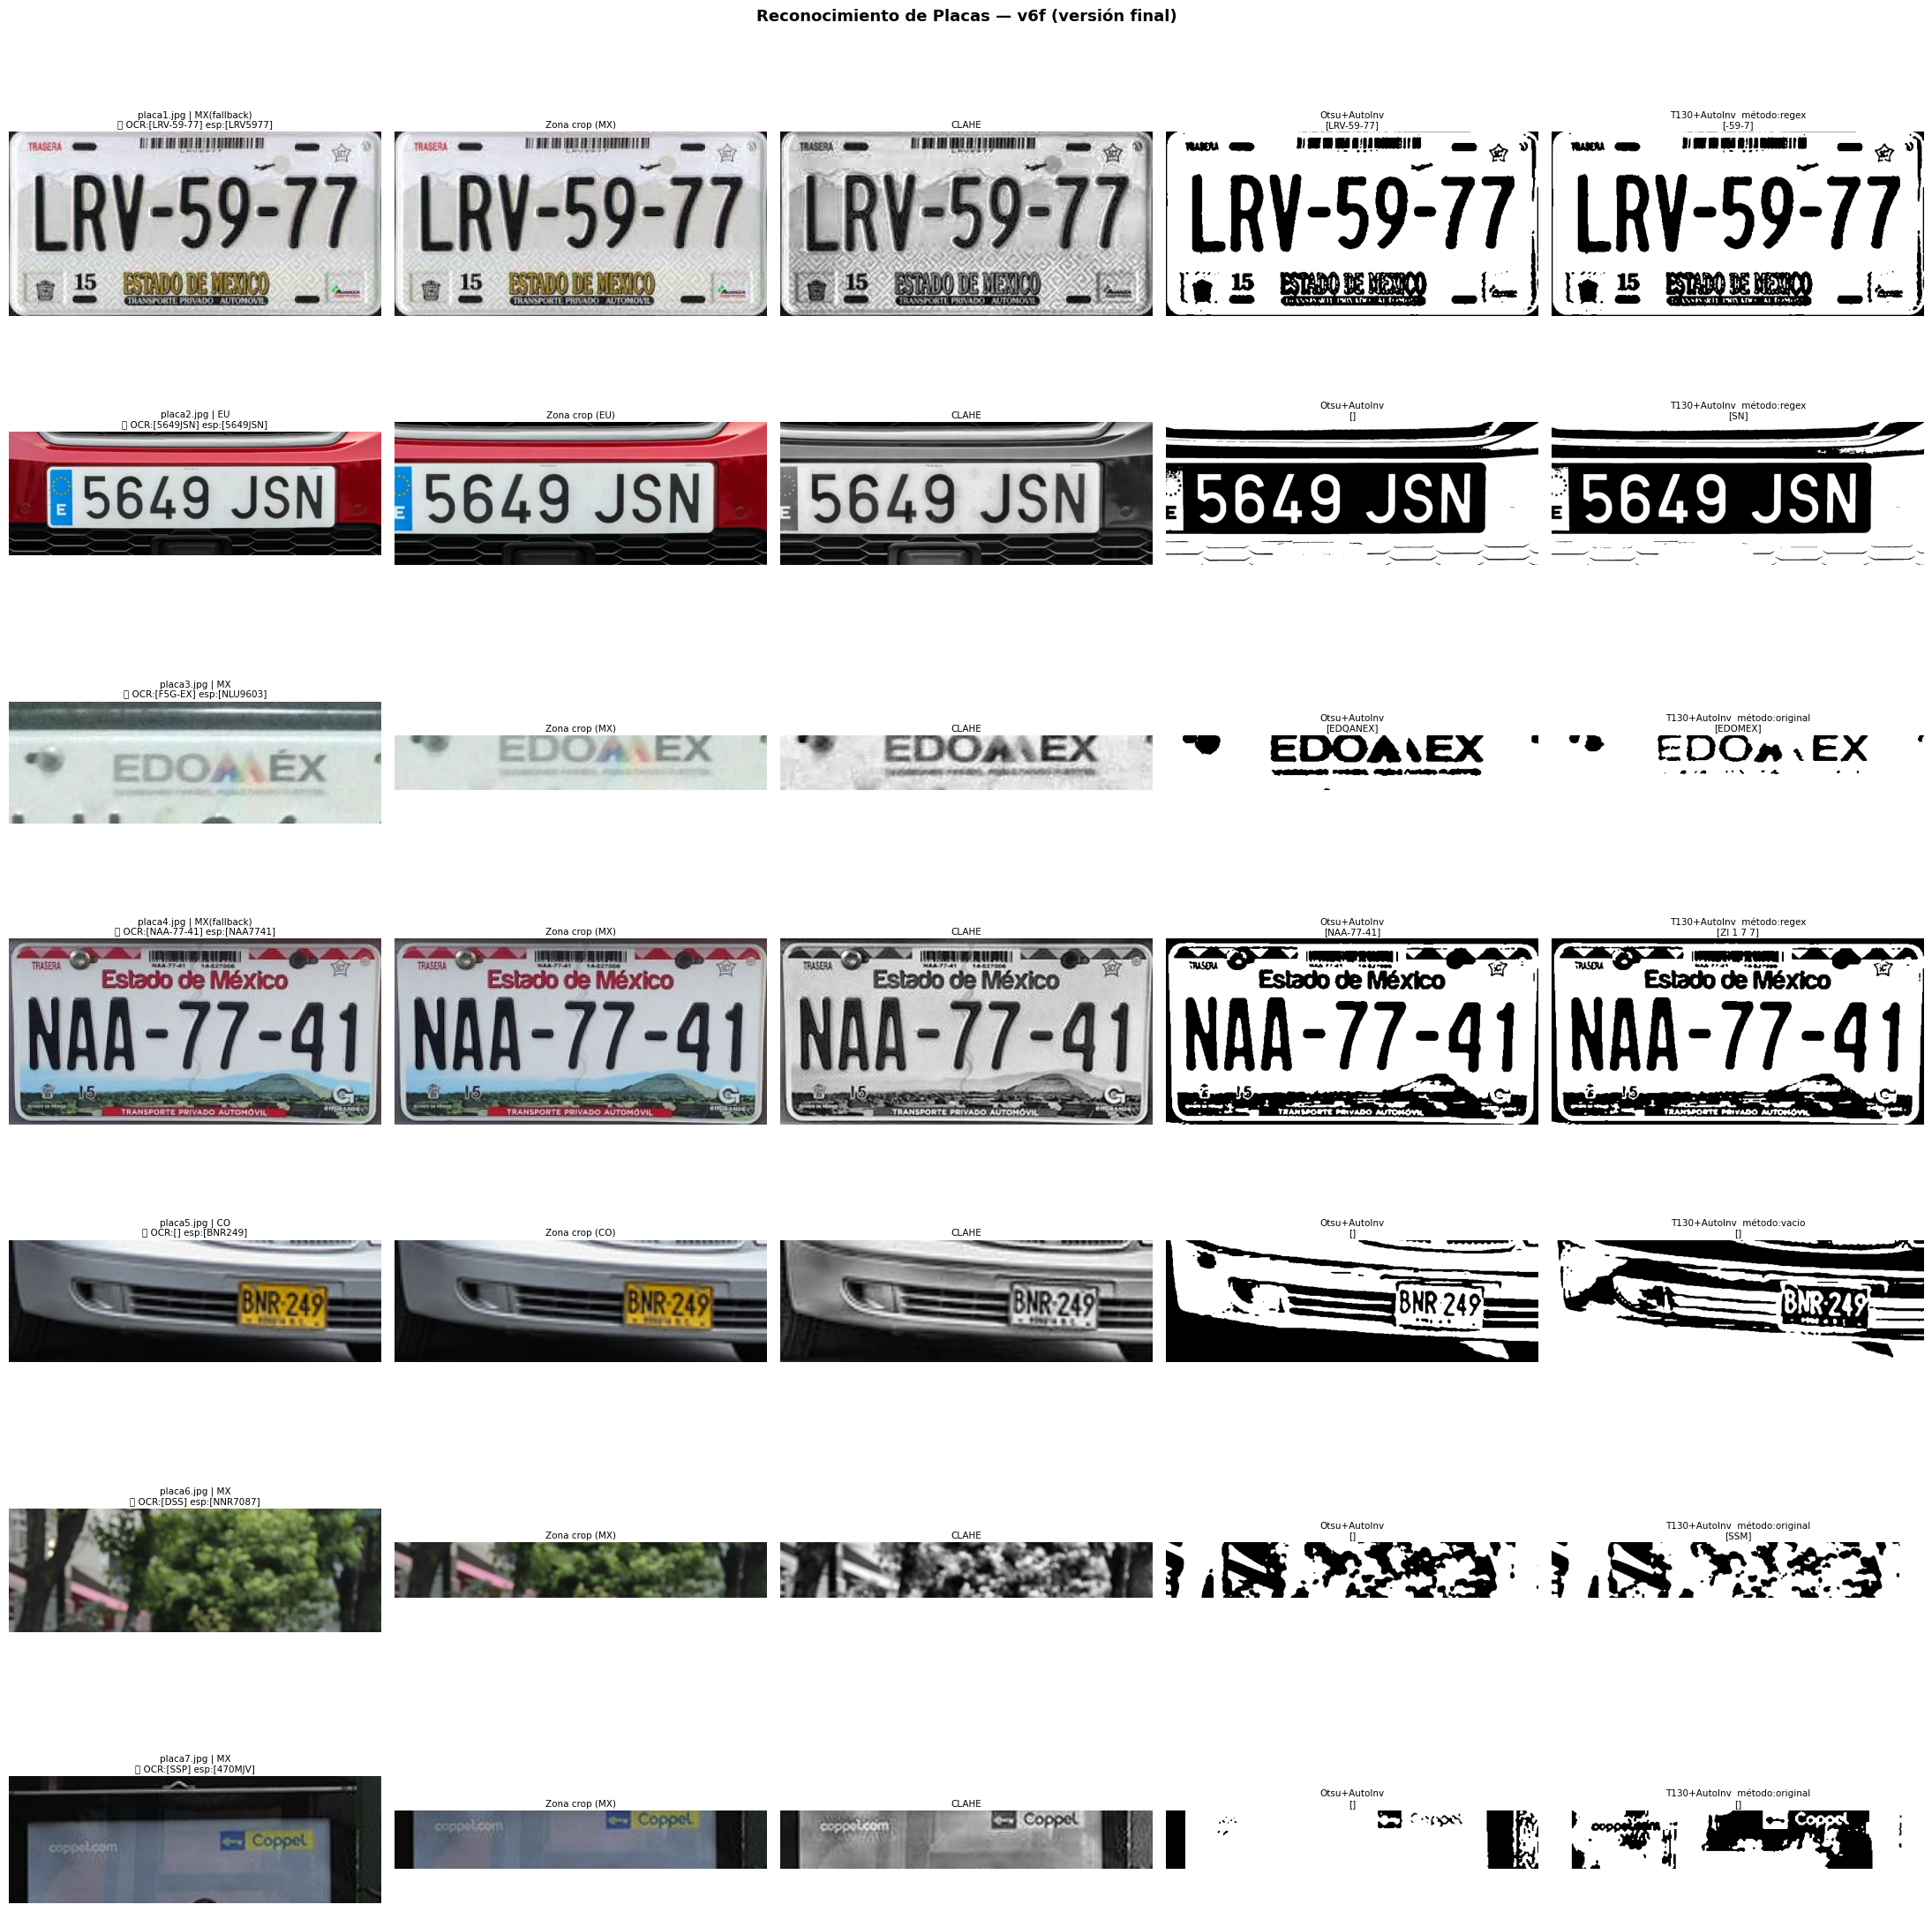

Grilla guardada: output_placas_v6f.png ✅


In [57]:
# ═══════════════════════════════════════════════════════════════
# CELDA 8 — Grilla visual
# Columnas: original | zona crop | CLAHE | Otsu+AutoInv | T130+AutoInv
# ═══════════════════════════════════════════════════════════════

n    = len(resultados)
fig,axes = plt.subplots(n,5,figsize=(22,3.2*n))
if n==1: axes=[axes]

for fila,r in enumerate(resultados):
    et = r['etapas']
    gt,_ = GROUND_TRUTH.get(r['imagen'],('?','?'))
    v    = verificar_ocr(r['texto'],gt)
    fb   = '(fallback)' if r['es_fallback'] else ''
    detalle_r = r.get('detalle', {})
    imgs_row = [
        (et['original'],True, f"{r['imagen']} | {r['tipo']}{fb}\n{v} OCR:[{r['texto']}] esp:[{gt}]"),
        (et['zona'],    True, f'Zona crop ({r["tipo"]})'),
        (et['clahe'],   False,'CLAHE'),
        (et['otsu'], False, f'Otsu+AutoInv\n[{detalle_r.get("otsu",("","",""))[1]}]'),
        (et['t130'],    False,f'T130+AutoInv  método:{r["metodo"]}\n[{r["detalle"].get("t130",("","",""))[1]}]'),
    ]
    for col,(img,es_color,titulo) in enumerate(imgs_row):
        ax = axes[fila][col]
        ax.imshow(img) if es_color else ax.imshow(img,cmap='gray')
        ax.set_title(titulo,fontsize=7.5,pad=3)
        ax.axis('off')

plt.suptitle('Reconocimiento de Placas — v6f (versión final)',
             fontsize=13,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('output_placas_v6f.png',dpi=120,bbox_inches='tight')
plt.show()
print('Grilla guardada: output_placas_v6f.png ✅')


### Ahora agremos el Data-Set propio

In [58]:
# ═══════════════════════════════════════════════════════════════
# CELDA 9 — Prueba con dataset propio (Plates_v2)
# ═══════════════════════════════════════════════════════════════

RUTA_PLACAS_V2 = os.path.join('..', 'Material', 'Plates_v2')

GROUND_TRUTH_V2 = {
    'coche1.jpeg': 'NZC736B',
    'coche2.jpeg': 'MJV245B',
    'coche3.jpeg': 'PDP8498',    # ligeramente inclinada
    'coche4.jpeg': 'MWY557C',    # ligeramente inclinada
    'Moto1.jpeg' : '4475C2',     # formato diferente (Moto EDOMEX)
    'moto2.jpeg' : '9J4UR',      # formato diferente (Moto CDMX)
}

imagenes_v2   = cargar_imagenes(RUTA_PLACAS_V2)  # sin prefijo = todas las fotos
resultados_v2 = []

print(f'Imágenes encontradas en Plates_v2: {len(imagenes_v2)}')

for ruta in imagenes_v2:
    nombre = os.path.basename(ruta)
    print(f'\n{"="*55}\n  {nombre}\n{"="*55}')

    img_rgb, recortes, coords, intento_ok = detectar_placas(ruta)
    if img_rgb is None: continue

    es_fallback     = (intento_ok == 0)
    recorte         = recortes[0]
    tipo, info_tipo = identificar_tipo_placa(recorte)
    texto, detalle, scores, mejor_var, etapas = extraer_texto(
        recorte, tipo=tipo, es_fallback=es_fallback)

    print(f'  Tipo : {tipo}  fallback={es_fallback}')
    print(f'  OCR  : [{texto}]  via={mejor_var}')

    resultados_v2.append({
        'imagen' : nombre,
        'tipo'   : tipo,
        'texto'  : texto,
        'recorte': recorte,
        'etapas' : etapas,
        'detalle': detalle,
    })
    
# Evaluación rápida del dataset propio
evaluables = [(r, GROUND_TRUTH_V2.get(r['imagen'],'')) 
              for r in resultados_v2 
              if GROUND_TRUTH_V2.get(r['imagen'],'')]
correctos_v2 = sum(1 for r,gt in evaluables 
                   if verificar_ocr(r['texto'],gt)=='✅')
if evaluables:
    print(f'\nAccuracy Plates_v2 (evaluables): '
          f'{correctos_v2}/{len(evaluables)} = '
          f'{correctos_v2/len(evaluables)*100:.0f}%')

print(f'\nTotal procesadas: {len(resultados_v2)} ✅')

Imágenes encontradas en Plates_v2: 6

  Moto1.jpeg
  Intento 3: 3 rechazada(s)
  Intento 4: 3 rechazada(s)
  Sin detecciones válidas → fallback imagen completa
  Tipo : MX  fallback=True
  OCR  : [BARRONS--38]  via=adapt

  coche1.jpeg
  Intento 2 (permisivo): 3 válida(s)
  Tipo : MX  fallback=False
  OCR  : [N7-736]  via=t160

  coche2.jpeg
  Intento 2: 1 rechazada(s)
  Intento 2 (permisivo): 1 válida(s)
  Tipo : MX  fallback=False
  OCR  : [JV-240-3]  via=t80

  coche3.jpeg
  Intento 3: 2 rechazada(s)
  Intento 4: 2 rechazada(s)
  Sin detecciones válidas → fallback imagen completa
  Tipo : MX  fallback=True
  OCR  : [P74-OS]  via=otsu

  coche4.jpeg
  Intento 2 (permisivo): 2 válida(s)
  Tipo : MX  fallback=False
  OCR  : [DR2BVRL]  via=otsu

  moto2.jpeg
  Intento 2: 1 rechazada(s)
  Intento 3: 9 rechazada(s)
  Intento 4: 9 rechazada(s)
  Sin detecciones válidas → fallback imagen completa
  Tipo : MX  fallback=True
  OCR  : [2YC--2]  via=t80

Accuracy Plates_v2 (evaluables): 0/6 = 0

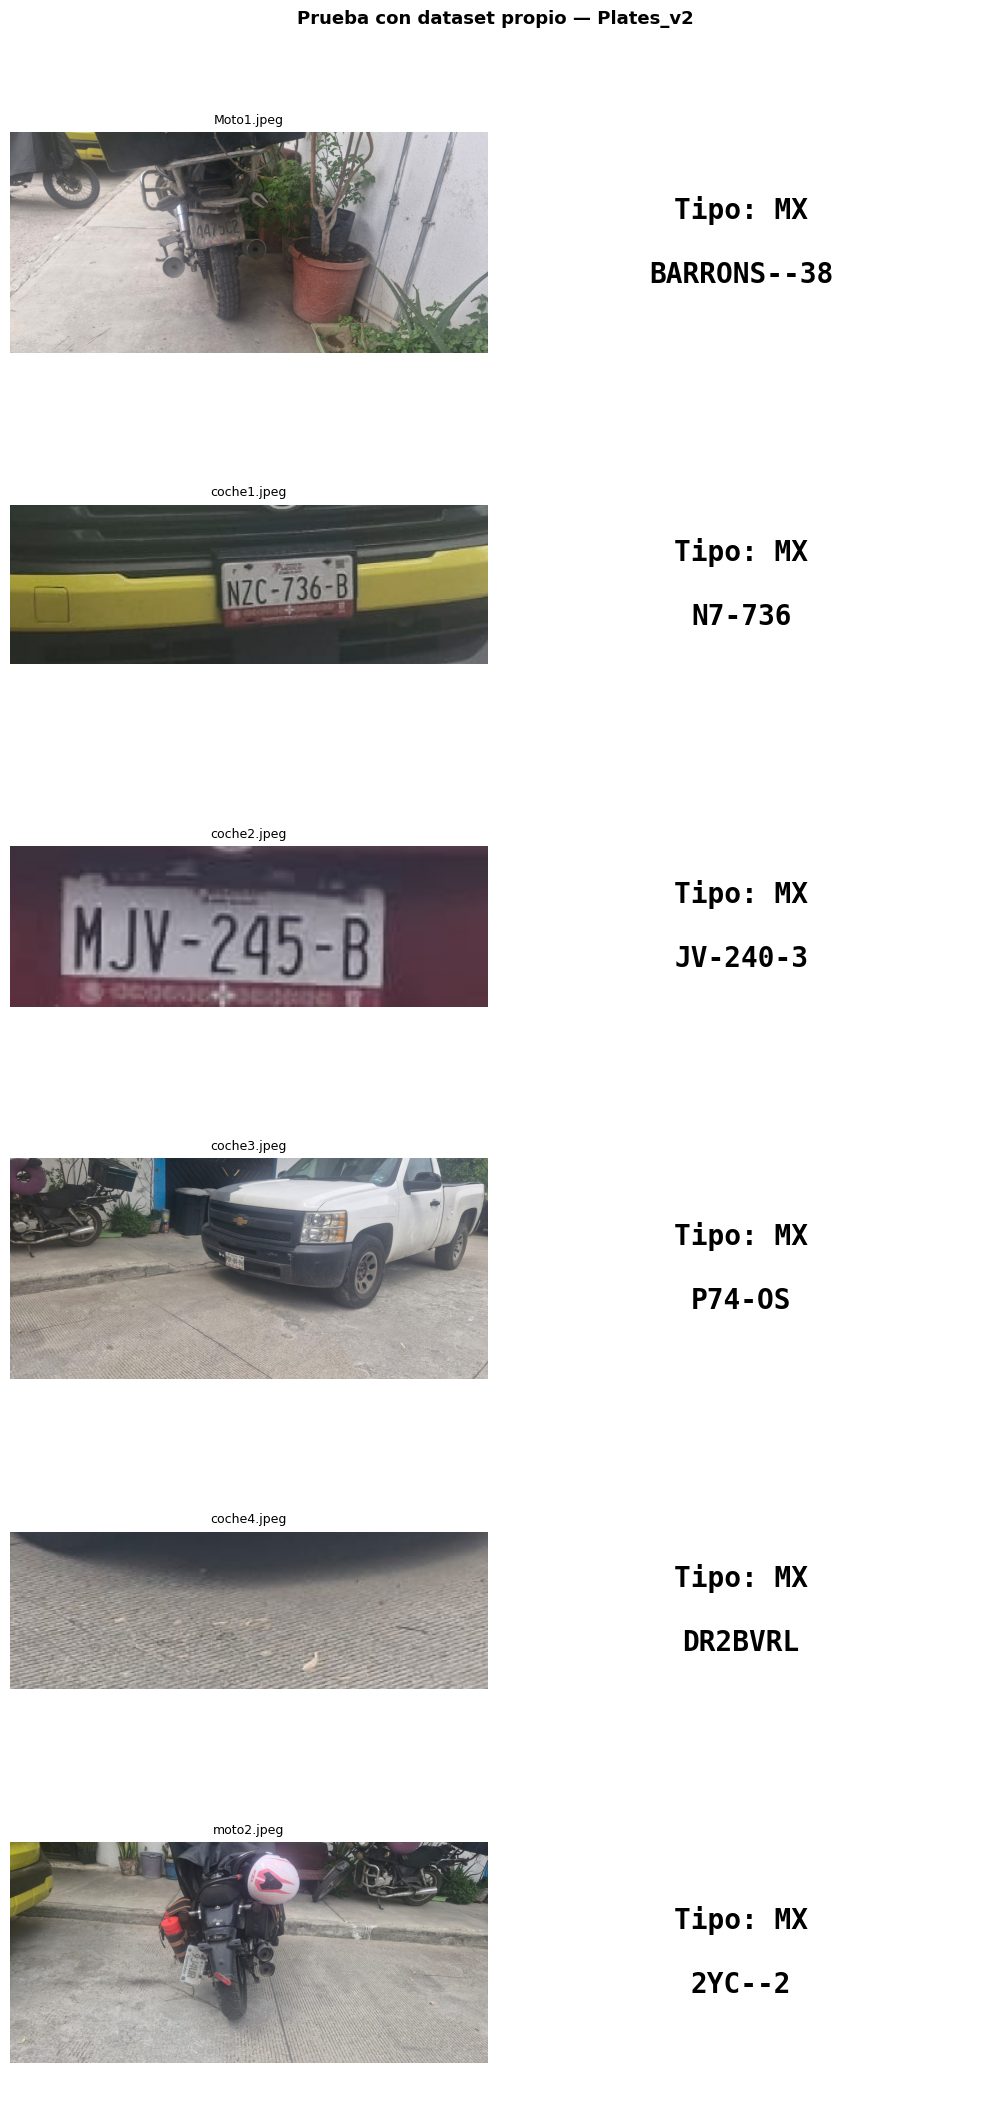

Tabla guardada: output_placas_v2_propio.png ✅


In [59]:
# ═══════════════════════════════════════════════════════════════
# CELDA 10 — Tabla visual: foto original + resultado OCR
# ═══════════════════════════════════════════════════════════════

n   = len(resultados_v2)
if n == 0:
    print('No hay imágenes en Plates_v2 todavía.')
else:
    fig, axes = plt.subplots(n, 2, figsize=(10, 3.5 * n))
    if n == 1: axes = [axes]

    for fila, r in enumerate(resultados_v2):
        # Columna 1: foto original del recorte detectado
        axes[fila][0].imshow(r['recorte'])
        axes[fila][0].set_title(r['imagen'], fontsize=9)
        axes[fila][0].axis('off')

        # Columna 2: resultado OCR en texto grande
        axes[fila][1].text(
            0.5, 0.5,
            f"Tipo: {r['tipo']}\n\n{r['texto'] if r['texto'] else '(sin lectura)'}",
            ha='center', va='center',
            fontsize=20, fontweight='bold',
            fontfamily='monospace',
            color='black' if r['texto'] else 'gray'
        )
        axes[fila][1].set_facecolor('#f8f8f8')
        axes[fila][1].axis('off')

    plt.suptitle('Prueba con dataset propio — Plates_v2',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('output_placas_v2_propio.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Tabla guardada: output_placas_v2_propio.png ✅')

## Conclusiones

### ¿Qué logramos?

Se implementó un pipeline completo de reconocimiento de placas vehiculares
usando técnicas de Visión por Computadora clásica (sin redes neuronales profundas),
evolucionando de v1 a v6f en 6 iteraciones documentadas.

---

### ¿Por qué fallan algunos casos?

**Placas en escenas de calle (placa5, placa6, placa7):**
El Haar Cascade fue entrenado para detectar placas en close-up.
En escenas con múltiples autos a distancia, la placa ocupa muy pocos píxeles
y el detector pierde precisión. Solución: detección en cascada (primero
detectar el vehículo con YOLO, luego buscar la placa dentro del ROI del auto).

**Placa de noche (placa3 — NLU-96-03):**
El Haar detectó la franja decorativa "EDOMEX" en lugar de los números,
porque esa zona tiene mayor contraste bajo luz artificial. El preprocesamiento
CLAHE mejora el contraste pero no puede recuperar información perdida por
condiciones de iluminación extremas.

**Motos (Moto1, moto2):**
Las placas de motocicleta tienen formato diferente (sin guiones intermedios
en CDMX, formatos estatales distintos), son más pequeñas y frecuentemente
aparecen inclinadas. El modelo no fue entrenado con ese tipo de placa.

**Lecturas parciales (coche1: N7-736 vs NZC-736-B):**
Tesseract confunde caracteres similares visualmente (N↔M, 0↔O, 5↔S)
en imágenes tomadas a distancia. A mayor distancia, menos píxeles por
carácter y mayor probabilidad de error.

---

### Pasos siguientes (trabajo futuro)

1. **Detección en cascada con YOLO:**
   Usar YOLOv8 preentrenado en COCO para detectar vehículos primero,
   luego aplicar el Haar Cascade solo dentro del ROI del vehículo.
   Esto resolvería placa5, placa6, placa7 y las fotos de coche a distancia.

2. **Corrección de perspectiva (deskew):**
   Aplicar transformación de perspectiva antes del OCR para corregir
   placas inclinadas. Útil para motos y fotos tomadas en ángulo.

3. **Motor OCR especializado:**
   Entrenar un modelo CRNN (Convolutional Recurrent Neural Network)
   con imágenes de placas mexicanas, o usar EasyOCR como complemento
   a Tesseract para mejorar la precisión en caracteres ambiguos.

4. **Validación de formato post-OCR:**
   Implementar corrección de errores conocidos (5↔S, 0↔O, 1↔I)
   basada en la posición esperada del carácter en el formato de la placa.

5. **Dataset más amplio:**
   El sistema actual fue desarrollado y probado con 13 imágenes en total.
   Un dataset de 500+ imágenes con variedad de condiciones permitiría
   evaluar y mejorar la robustez del pipeline.